# RideWise · Notebook 02 — Exploratory Data Analysis

**Understand trip economics, city and loyalty patterns, and what the churn landscape looks like before modelling.**

---

### What you will learn
- How to profile distributions that matter for a mobility business
- How surge, weather, payment and city interact with revenue
- How to read engagement from the sessions table
- How to frame EDA around the questions a model will later answer

### How to read this notebook
Every section follows the same rhythm used throughout the project:
**the business question first**, then the data, then the method, then a
**validation check** that proves the step did what we claimed. Run the cells
top to bottom; nothing depends on hidden state.

---

## 1. The business question

EDA is not a slideshow of every chart you can make. It answers: **which
behaviours vary between riders, and which of those might explain churn?**
We keep that lens throughout.

In [1]:
# --- environment setup  ---
from pathlib import Path

import numpy as np
import pandas as pd
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

# Project-wide constants used throughout the notebooks
RANDOM_STATE = 42                            # Set a random seed for reproducibility
CHURN_WINDOW_DAYS = 30                       # inactivity window that defines churn
LOYALTY_ORDER = {"Bronze": 0, "Silver": 1, "Gold": 2, "Platinum": 3}            # Define loyalty tier order for sorting and analysis

# Where the raw CSVs live (this notebook sits in notebooks/, data in ../data/)
DATA_DIR = Path("../data") if Path("../data").exists() else Path("data")        # Define the data directory path based on the current working directory

NAVY, ACCENT = "#1F3A5F", "#C8843C"                                         # Define color palette for plots
print("Libraries imported · data directory:", DATA_DIR.resolve())

Libraries imported · data directory: C:\Users\woro_\OneDrive\DS_Projects\Ride-hailing_Analytics_and_Churn_Prediction\data


In [2]:
# Load data
   
riders = pd.read_csv('../data/riders_clean.csv')
drivers = pd.read_csv('../data/drivers.csv')
trips = pd.read_csv('../data/trips_clean.csv')
sessions = pd.read_csv('../data/sessions.csv')
promotions = pd.read_csv('../data/promotions.csv')


In [3]:
"""Parse timestamps"""
trips['pickup_time'] = pd.to_datetime(trips['pickup_time'], errors='coerce')
trips['dropoff_time'] = pd.to_datetime(trips['dropoff_time'], errors='coerce')
riders['signup_date'] = pd.to_datetime(riders['signup_date'], errors='coerce')

In [4]:
riders.head(3)

,user_id,signup_date,loyalty_status,age,city,avg_rating_given,churn_prob,referred_by,was_referred
0,R00000,2025-01-24 00:00:00+00:00,Bronze,35.0,Nairobi,5.0,0.142431,R00001,1
1,R00001,2024-09-09 00:00:00+00:00,Bronze,35.0,Nairobi,4.7,0.674161,NaN,0
2,R00002,2024-09-07 00:00:00+00:00,Bronze,47.0,Lagos,4.2,0.510379,NaN,0


In [5]:
riders.dtypes

user_id                             str
signup_date         datetime64[us, UTC]
loyalty_status                      str
age                             float64
city                                str
avg_rating_given                float64
churn_prob                      float64
referred_by                         str
was_referred                      int64
dtype: object

In [6]:
trips.head(3)

,trip_id,user_id,driver_id,fare,surge_multiplier,tip,payment_type,pickup_time,dropoff_time,pickup_lat,pickup_lng,dropoff_lat,dropoff_lng,weather,city,loyalty_status,duration_min
0,T000000,R05207,D00315,12.11,1.0,0.00,Card,2024-11-27 16:14:50+00:00,2024-11-27 17:06:50+00:00,-1.108123,36.912209,-1.068155,36.875377,Foggy,Nairobi,Bronze,52.0
1,T000001,R09453,D03717,8.73,1.0,0.02,Card,2024-10-28 22:59:48+00:00,2024-10-28 23:12:48+00:00,6.675266,3.515740,6.641734,3.525620,Sunny,Lagos,Gold,13.0
2,T000002,R00567,D02035,19.68,1.0,0.00,Card,2025-02-17 03:09:41+00:00,2025-02-17 03:25:41+00:00,-1.248589,37.010668,-1.273182,37.018586,Cloudy,Nairobi,Bronze,16.0


In [7]:
trips.dtypes

trip_id                             str
user_id                             str
driver_id                           str
fare                            float64
surge_multiplier                float64
tip                             float64
payment_type                        str
pickup_time         datetime64[us, UTC]
dropoff_time        datetime64[us, UTC]
pickup_lat                      float64
pickup_lng                      float64
dropoff_lat                     float64
dropoff_lng                     float64
weather                             str
city                                str
loyalty_status                      str
duration_min                    float64
dtype: object

## 2. Trip economics: fare, surge and tips

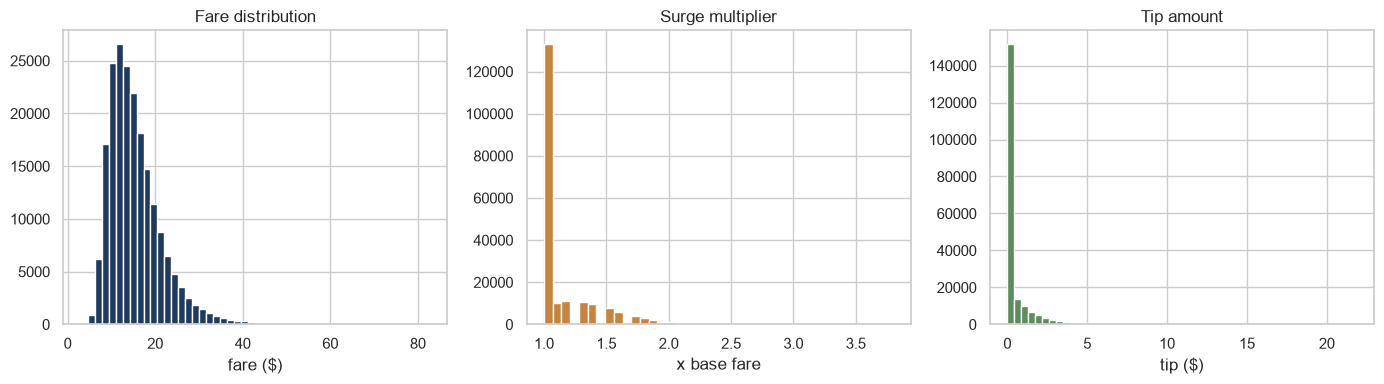

Median fare: $14.13
Share of trips with surge > 1.0: 33.6%
Share of trips with a tip: 34.3%


In [8]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
ax[0].hist(trips["fare"], bins=50, color=NAVY); ax[0].set_title("Fare distribution"); ax[0].set_xlabel("fare ($)")
ax[1].hist(trips["surge_multiplier"], bins=40, color=ACCENT); ax[1].set_title("Surge multiplier"); ax[1].set_xlabel("x base fare")
ax[2].hist(trips["tip"], bins=50, color="#5B8C5A"); ax[2].set_title("Tip amount"); ax[2].set_xlabel("tip ($)")
plt.tight_layout(); plt.show()

print("Median fare: $%.2f" % trips["fare"].median())
print("Share of trips with surge > 1.0: %.1f%%" % ((trips["surge_multiplier"] > 1.0).mean() * 100))
print("Share of trips with a tip: %.1f%%" % ((trips["tip"] > 0).mean() * 100))

**Reading it:** most fares cluster in a tight band, surge is occasional but
real, and tipping is the exception not the rule. Surge exposure and tipping
behaviour are both candidate churn signals — frustrated, surged riders may
leave; generous tippers may be more committed.

## 3. City and loyalty structure

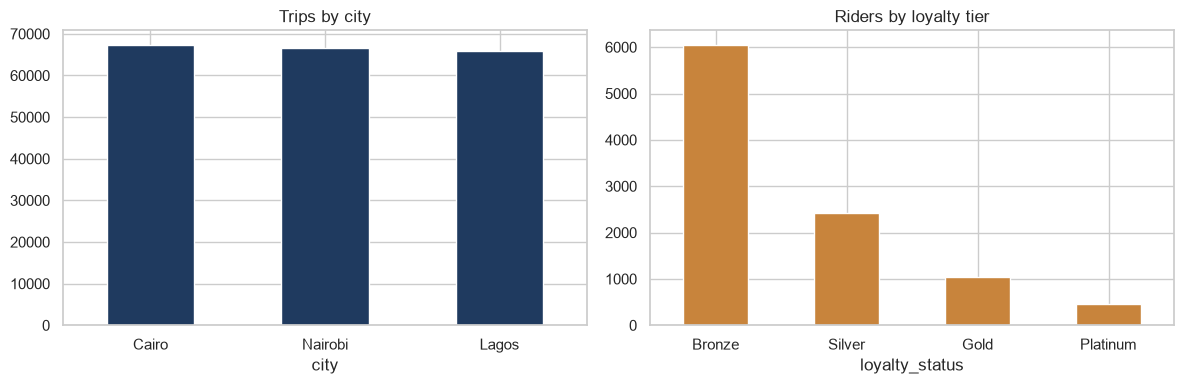

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
trips["city"].value_counts().plot.bar(ax=ax[0], color=NAVY); ax[0].set_title("Trips by city"); ax[0].tick_params(axis="x", rotation=0)
riders["loyalty_status"].value_counts().reindex(["Bronze","Silver","Gold","Platinum"]).plot.bar(ax=ax[1], color=ACCENT)
ax[1].set_title("Riders by loyalty tier"); ax[1].tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

## 4. When do people ride? (temporal habits)

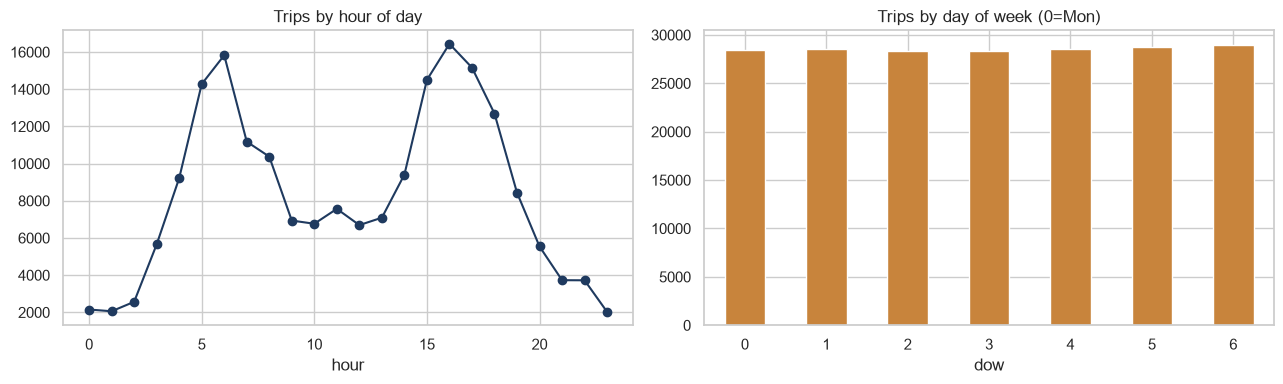

In [10]:
trips["hour"] = trips["pickup_time"].dt.hour
trips["dow"] = trips["pickup_time"].dt.dayofweek
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
trips["hour"].value_counts().sort_index().plot(ax=ax[0], color=NAVY, marker="o")
ax[0].set_title("Trips by hour of day"); ax[0].set_xlabel("hour")
trips.groupby("dow").size().plot.bar(ax=ax[1], color=ACCENT)
ax[1].set_title("Trips by day of week (0=Mon)"); ax[1].tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

**Reading it:** the spread of riding hours and weekday/weekend balance differ
from rider to rider. We will turn these into `night_ratio` and `weekend_ratio`
features, because *how* someone rides can separate a committed
commuter from a casual weekend user.

## 5. Engagement from sessions

Overall in-app conversion rate: 15.6%


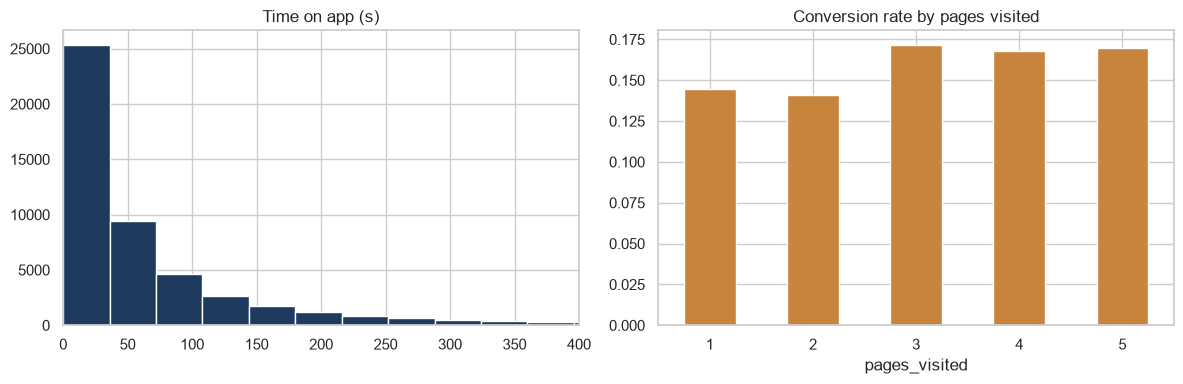

In [11]:
print("Overall in-app conversion rate: %.1f%%" % (sessions["converted"].mean() * 100))
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(sessions["time_on_app"], bins=50, color=NAVY); ax[0].set_title("Time on app (s)"); ax[0].set_xlim(0, 400)
sessions.groupby("pages_visited")["converted"].mean().plot.bar(ax=ax[1], color=ACCENT)
ax[1].set_title("Conversion rate by pages visited"); ax[1].tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

## 6. Summary

- Fares are tight; surge and tipping are informative minorities.
- Three cities and four loyalty tiers give natural cohorts.
- Temporal and engagement behaviour vary across riders — the raw material for features.